In [48]:
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import get_train_test_data, train_mlp, train_baseline_model
from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.config import Config
from ml_baselines.data import read_agage, read_intem
from ml_baselines.modelling.plot import plot_confusion_matrix
from ml_baselines.modelling.predict import BaselineLabelledObservations


In [49]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
cfg = Config()
site = "MHD"

## plotting obs from a trained model

In [142]:
model, _,_  = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights="auto", return_scores=False, verbose=False)

In [ ]:
## a trained model could be loaded here instead

Use predict_baselines to produce predictions for a trained model, on a specific chunk of the dataset, using a custom prediction threshold. For example, `prediction_mode="validation"` returns the true and predicted labels and the metrics on that dataset. 

In [143]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=0.75)

Predicting on validation set for site: MHD with prediction threshold: 0.75
Loading data for site: MHD, period: 2019-2019
Precision: 0.638
Recall: 0.185
F1 Score: 0.287


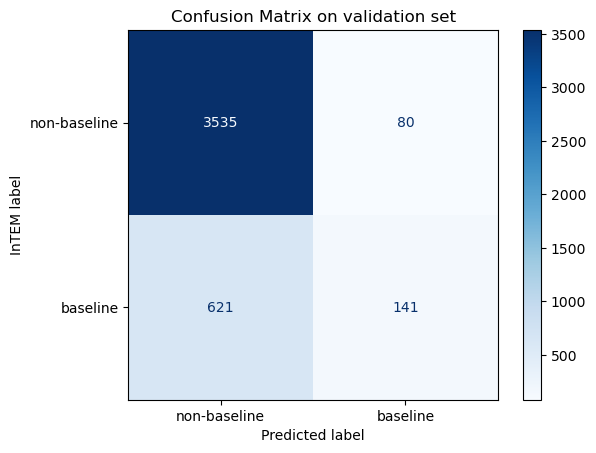

In [144]:
plot_confusion_matrix(y, y_pred, normalise=False, title="Confusion Matrix on validation set")

### load some observations, and predict baselines for the full period for plotting purposes

Use `prediction_mode="full"` to generate labels on the whole available dataset which is useful for plotting. The full period can be specified in the config file, or otherwise it is the stacked training-validation-test sets.

In [145]:
y, y_pred, y_proba, ymetrics = predict_baselines("MHD", model, prediction_mode="full", prediction_threshold=0.5, return_proba=True)

Predicting on full set for site: MHD with prediction threshold: 0.5
Loading data for site: MHD, period: 2010-2023


Precision: 0.656
Recall: 0.680
F1 Score: 0.668


In [146]:
site = "MHD"
species = "hfc-134a".lower() #"hfc-134a" 
start_year=2010
end_year=2023

In [147]:
df_agage = read_agage(site, species, start_year=start_year, end_year=end_year)

The object `BaselineLabelledObservations` takes in a dataset of measurements (e.g. from agage) and aligns it with the true and predicted labels from the model. It can plot the observations and labels, calculate the monthly means and plot those.

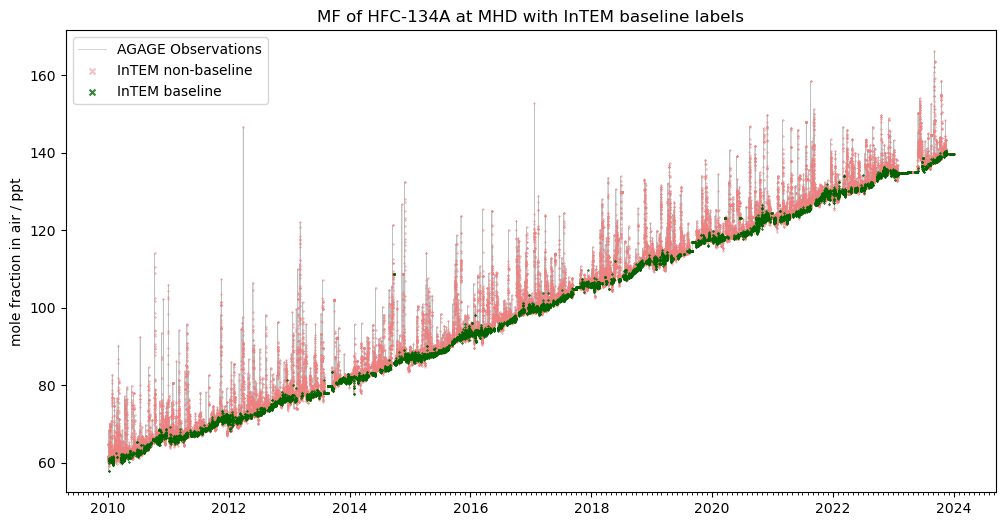

In [148]:
labelled_obs = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
labelled_obs.plot_obs()  

In this plot, each quarter of the confusion matrix is plotted separately, showing what labels the model gets right (dark green and light pink) and which ones it doesn't

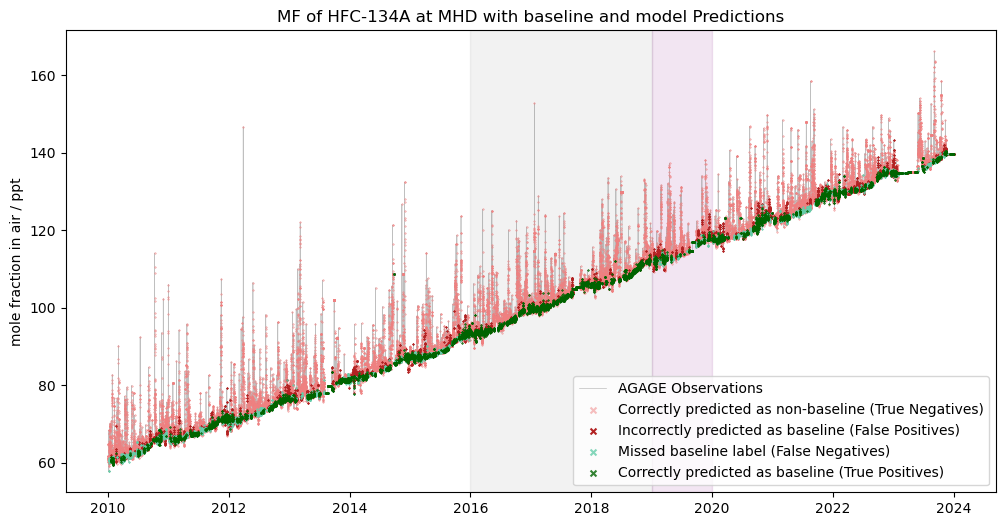

In [149]:
labelled_obs.plot_obs_with_labels(plot_true_negatives=True)

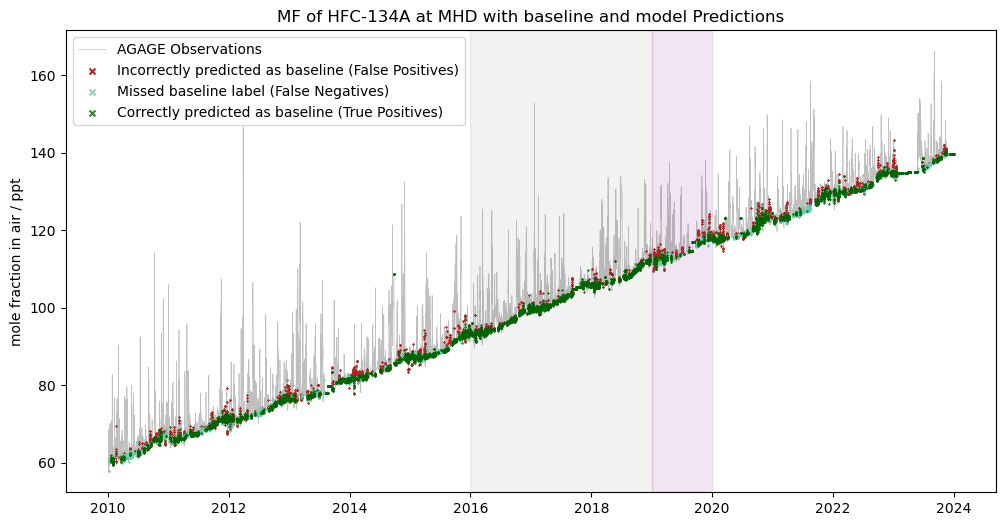

In [150]:
# i actually think that plotting the true negatives is helpful! but for comparison
labelled_obs.plot_obs_with_labels(plot_true_negatives=False)

In [151]:
labelled_obs.get_prediction_scores()

train set - Precision: 0.882, Recall: 0.998, F1 Score: 0.937
valida set - Precision: 0.495, Recall: 0.615, F1 Score: 0.549
test set - Precision: 0.591, Recall: 0.571, F1 Score: 0.581
full set - Precision: 0.656, Recall: 0.680, F1 Score: 0.668


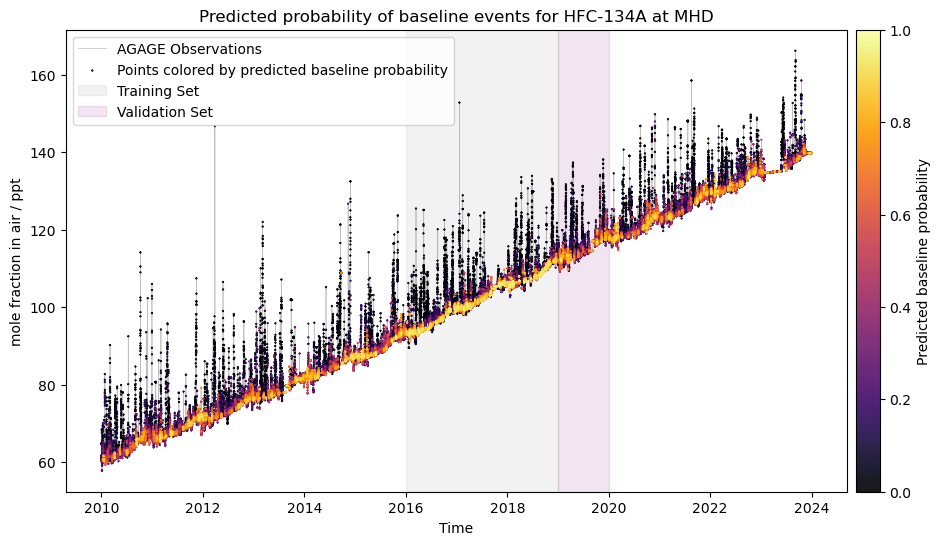

In [152]:
# we can also see where the model is more confident
labelled_obs.plot_model_confidence(cmap="inferno")

the object calculates the monthly means and plots them, with or without the observations in the background. If the model has predicted no baselines for a particular month this is shown in red - it can happen particularly for high thresholds

In [153]:
labelled_obs.calculate_monthly_means()

Found 0 missing months, and 23 anomaly months (with 20, 3, and 0 months with deviations greater than 1, 3, and 5 standard deviations respectively).


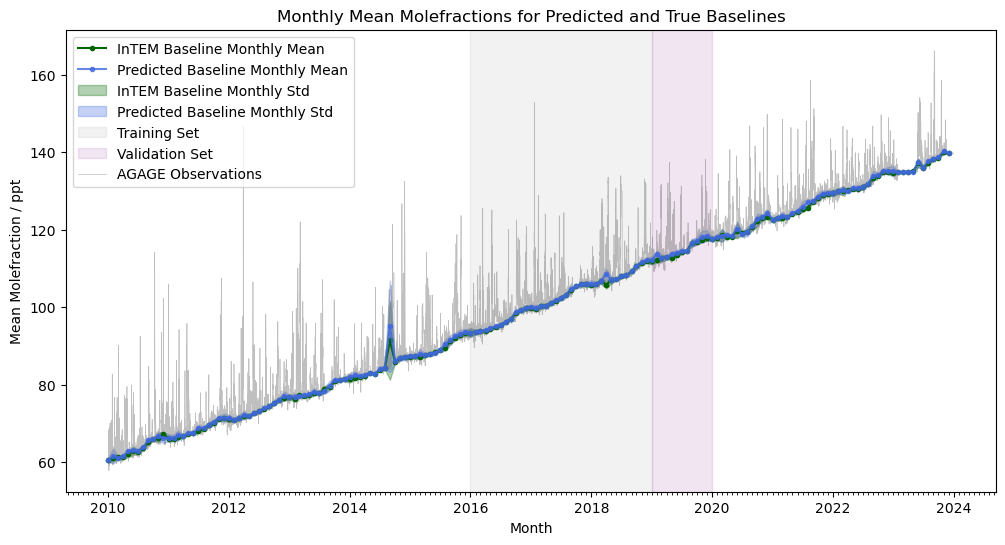

In [154]:
labelled_obs.plot_monthly_means()

this plot has a few different options, for example whether to plot the observations in the background, whether to indicate anomalies, or to show a histogram of obs

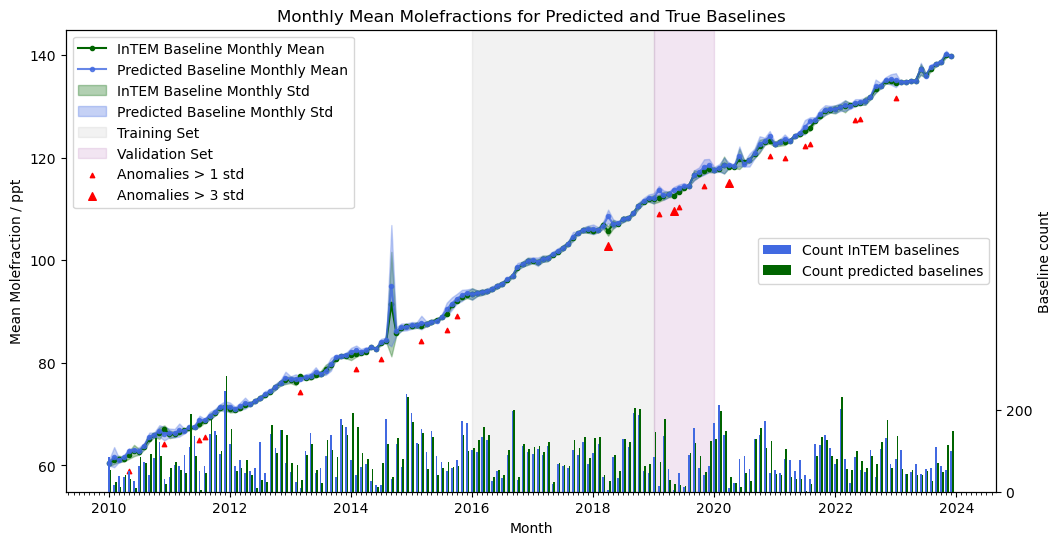

In [155]:
labelled_obs.plot_monthly_means(show_anomalies=True, plot_obs=False, plot_count_hist=True)

In [156]:
labelled_obs.print_monthly_stats()
# these are also stored in self.monthly_scores

train set - MAE: 0.155, MAPE: 0.149%, bias: 0.144, RMSE: 0.486
valida set - MAE: 0.494, MAPE: 0.433%, bias: 0.486, RMSE: 0.697
test set - MAE: 0.240, MAPE: 0.189%, bias: 0.205, RMSE: 0.350
full set - MAE: 0.271, MAPE: 0.292%, bias: 0.227, RMSE: 0.498


## comparing

the data object makes it easier to compare different models or thresholds

Predicting on full set for site: MHD with prediction threshold: 0.5
Loading data for site: MHD, period: 2010-2023
Precision: 0.656
Recall: 0.680
F1 Score: 0.668


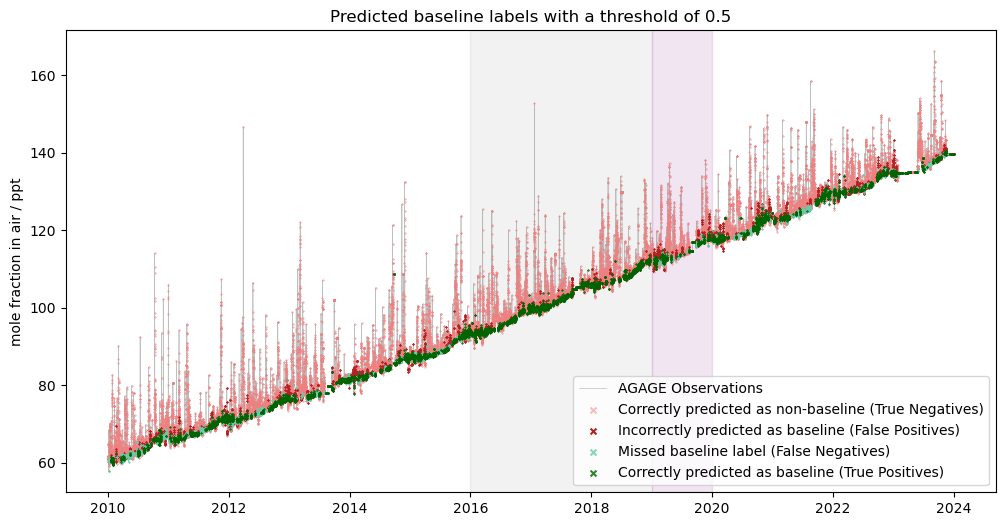

In [157]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="full", prediction_threshold=0.5)
labelled_obs_05 = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site)
labelled_obs_05.plot_obs_with_labels(plot_true_negatives=True, title="Predicted baseline labels with a threshold of 0.5")

Predicting on full set for site: MHD with prediction threshold: 0.75
Loading data for site: MHD, period: 2010-2023
Precision: 0.856
Recall: 0.336
F1 Score: 0.482


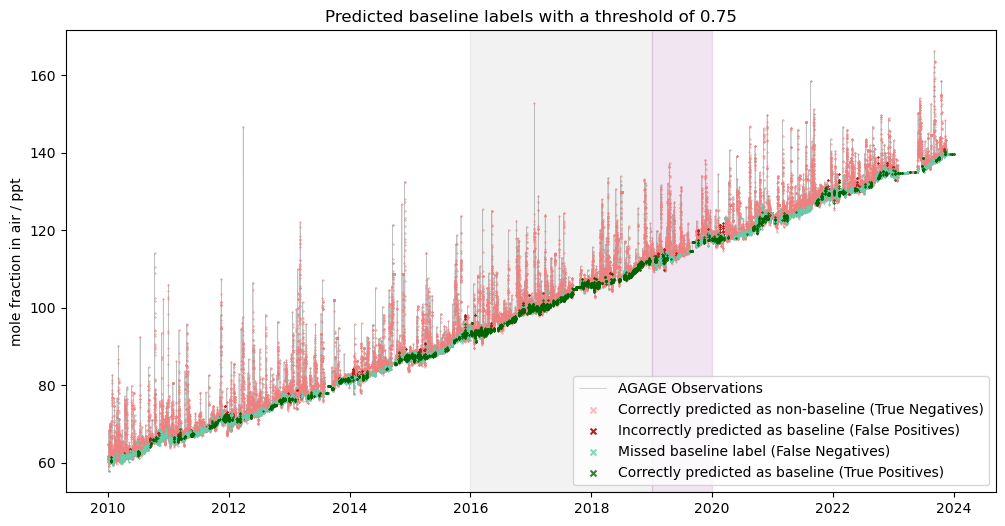

In [158]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="full", prediction_threshold=0.75)
labelled_obs_075 = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site)
labelled_obs_075.plot_obs_with_labels(plot_true_negatives=True, title="Predicted baseline labels with a threshold of 0.75")

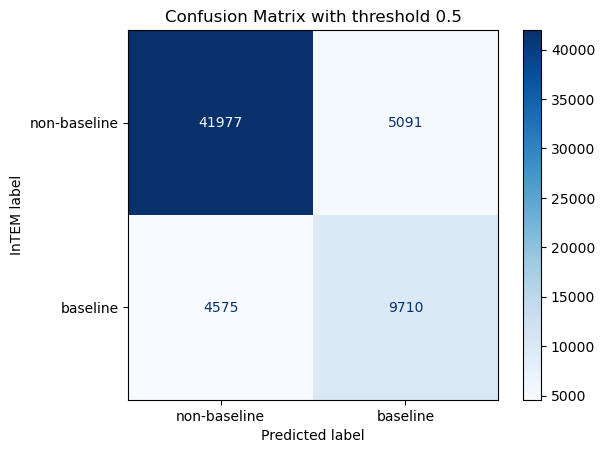

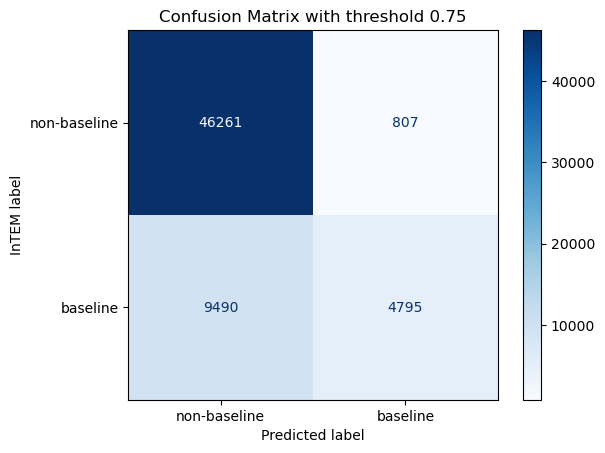

In [159]:
labelled_obs_05.plot_confusion_matrix(normalise=False, title="Confusion Matrix with threshold 0.5")
labelled_obs_075.plot_confusion_matrix(normalise=False, title="Confusion Matrix with threshold 0.75")

using a higher threshold means more missing months but fewer anomalies

Found 0 missing months, and 23 anomaly months (with 20, 3, and 0 months with deviations greater than 1, 3, and 5 standard deviations respectively).


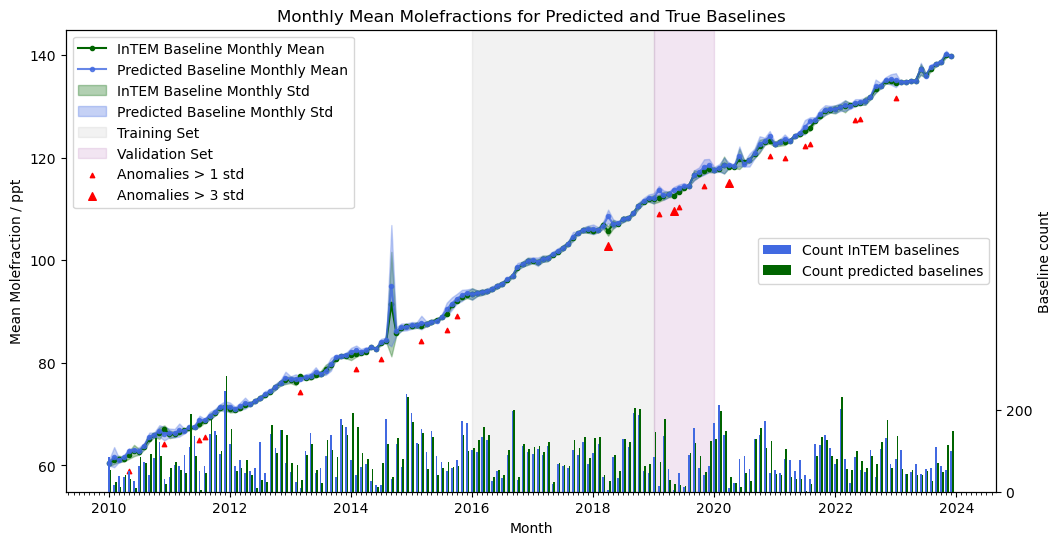

In [160]:
labelled_obs_05.plot_monthly_means(show_anomalies=True, plot_obs=False, plot_count_hist=True)

Found 19 missing months, and 15 anomaly months (with 13, 2, and 0 months with deviations greater than 1, 3, and 5 standard deviations respectively).


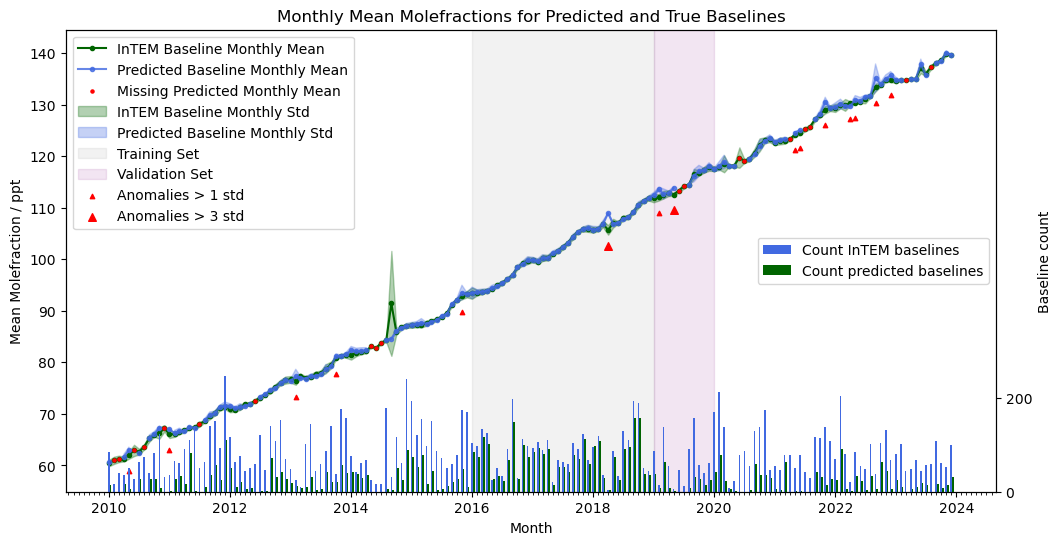

In [161]:
labelled_obs_075.plot_monthly_means(show_anomalies=True, plot_obs=False, plot_count_hist=True)

## across a number of gases

In [ ]:
site = "MHD"
species = "hfc-134a".lower() #"hfc-134a" 
start_year=2010
end_year=2023

In [ ]:
species_list = ["hfc-134a", "hfc-152a", "hfc-125", "hfc-143a", "hfc-227ea", "hfc-236fa"]

In [141]:
# could use this loop to plot confusion matrix from paper

In [130]:
species_scores = {}
for species in species_list:
    df_agage = read_agage(site, species, start_year=start_year, end_year=end_year)
    labelled_obs_here = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
    labelled_obs_here.print_monthly_stats()
    species_scores[species] = labelled_obs_here.monthly_scores

Found 0 missing months, and 23 anomaly months (with 20, 3, and 0 months with deviations greater than 1, 3, and 5 standard deviations respectively).
train set - MAE: 0.155, MAPE: 0.149%, bias: 0.144, RMSE: 0.486
valida set - MAE: 0.494, MAPE: 0.433%, bias: 0.486, RMSE: 0.697
test set - MAE: 0.240, MAPE: 0.189%, bias: 0.205, RMSE: 0.350
full set - MAE: 0.271, MAPE: 0.292%, bias: 0.227, RMSE: 0.498
Found 0 missing months, and 31 anomaly months (with 24, 2, and 5 months with deviations greater than 1, 3, and 5 standard deviations respectively).
train set - MAE: 0.134, MAPE: 1.296%, bias: 0.126, RMSE: 0.393
valida set - MAE: 0.370, MAPE: 3.420%, bias: 0.367, RMSE: 0.480
test set - MAE: 0.184, MAPE: 1.725%, bias: 0.158, RMSE: 0.252
full set - MAE: 0.190, MAPE: 1.838%, bias: 0.156, RMSE: 0.309
Found 0 missing months, and 24 anomaly months (with 21, 0, and 3 months with deviations greater than 1, 3, and 5 standard deviations respectively).
train set - MAE: 0.045, MAPE: 0.164%, bias: 0.038, RMS

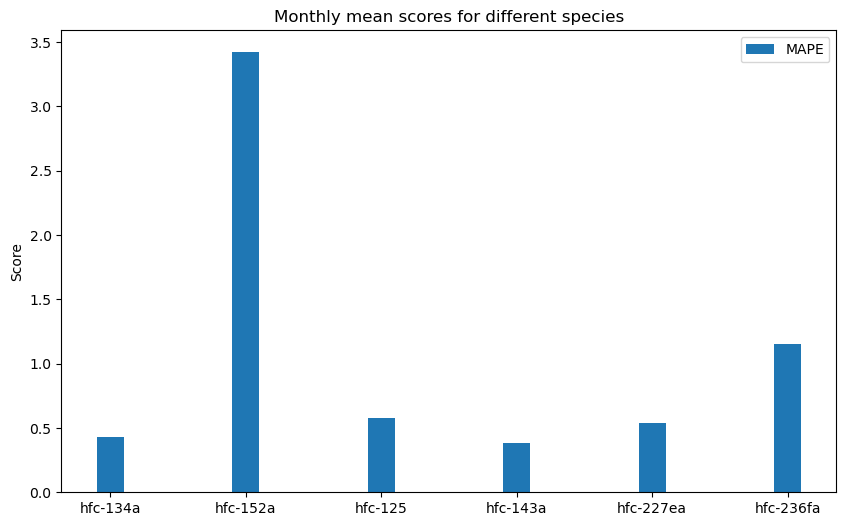

In [ ]:
metric = "MAPE"
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(species_list))
width = 0.2
scores = [100*species_scores[species]["validation"][metric] for species in species_list]
ax.bar(x, scores, width=width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(species_list)
ax.set_ylabel("Score")
ax.set_title("Monthly mean scores for different species")
ax.legend()
plt.show()
 

## other experiments

In [ ]:
params_dict = {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 50, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'adam'}
model, X, y = train_baseline_model(site, model_type="mlp", model_params=params_dict, return_scores=False, verbose=True)

In [4]:
model, x, y = train_baseline_model("MHD", model_type="random_forest",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=10)

Training random_forest model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 0.674
Precision on Validation Set = 0.428
Precision on Test Set = 0.524
Recall on Training Set = 1.000
Recall on Validation Set = 0.744
Recall on Test Set = 0.738
F1 Score on Training Set = 0.805
F1 Score on Validation Set = 0.543
F1 Score on Test Set = 0.613


In [4]:
model, x, y = train_baseline_model("MHD", model_type="gradient_boosting",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_features":"sqrt", "subsample":0.8}, sample_weights=10)

Training gradient_boosting model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 1.000
Precision on Validation Set = 0.479
Precision on Test Set = 0.567
Recall on Training Set = 1.000
Recall on Validation Set = 0.591
Recall on Test Set = 0.555
F1 Score on Training Set = 1.000
F1 Score on Validation Set = 0.529
F1 Score on Test Set = 0.561


In [12]:
metric_dict = {}
thr_values = [0.25, 0.5, 0.75, 0.8, 0.9]
for threshold in thr_values:
    y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=threshold)
    metric_dict[threshold] = metrics

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.25
Precision: 0.338
Recall: 0.945
F1 Score: 0.498
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.428
Recall: 0.744
F1 Score: 0.543
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.524
Recall: 0.421
F1 Score: 0.467
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.8
Precision: 0.567
Recall: 0.333
F1 Score: 0.420
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.9
Precision: 0.681
Recall: 0.081
F1 Score: 0.145


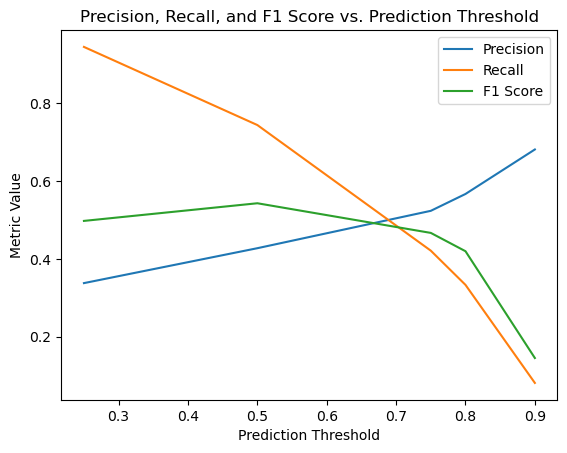

In [13]:
plt.plot(thr_values, [metric_dict[thr]["precision"] for thr in thr_values], label="Precision")
plt.plot(thr_values, [metric_dict[thr]["recall"] for thr in thr_values], label="Recall")
plt.plot(thr_values, [metric_dict[thr]["f1"] for thr in thr_values], label="F1 Score")
plt.xlabel("Prediction Threshold")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Prediction Threshold")
plt.legend()

In [35]:
weights_dict = {}
weights_list = [1,2,4,10,20]
for weight in weights_list:
    _, _, _, metrics = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=weight, return_scores=True, verbose=False, prediction_threshold=0.75)
    weights_dict[weight] = metrics

Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5


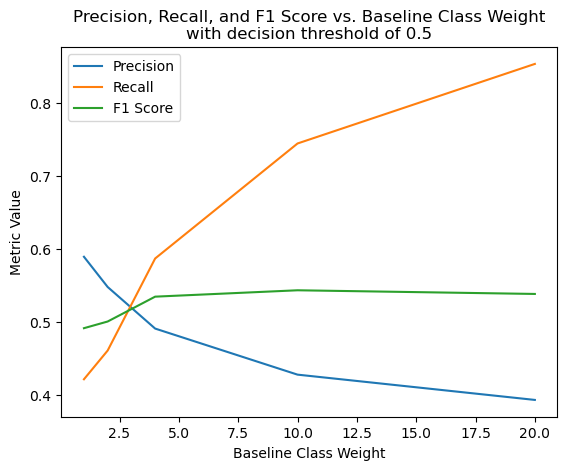

In [33]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.5")
plt.legend()

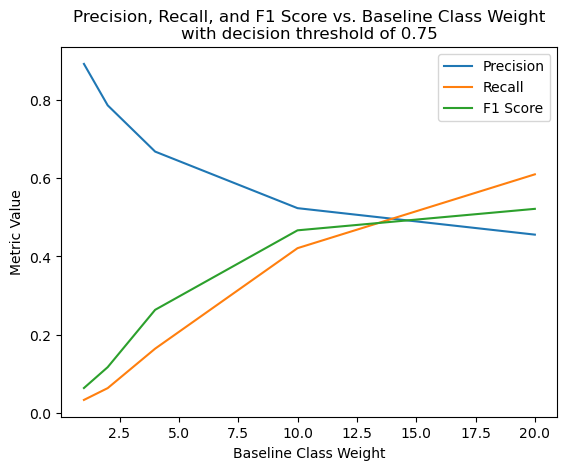

In [36]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.75")
plt.legend()

In [38]:
model, _,_  = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights="auto", return_scores=False, verbose=False)

In [ ]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=0.75)

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.638
Recall: 0.185
F1 Score: 0.287


In [5]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="test", prediction_threshold=0.5)

Predicting on test set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.524
Recall: 0.738
F1 Score: 0.613
